# Exploratory Data Analysis (EDA)

In this notebook, exploratory data analysis is performed on the cleaned Melbourne parking datasets. The main aim is to identify temporal and spatial patterns in parking demand, such as hourly trends, day-based variation, zone-based demand, and the impact of parking restrictions.

Two processed datasets are used in this analysis:

1. `merged_bay_sensor_data.csv`  
2. `cleaned_demand_data.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [3]:
merged_df = pd.read_csv("../data/processed/merged_bay_sensor_data.csv")
demand_df = pd.read_csv("../data/processed/cleaned_demand_data.csv")

In [4]:
print("Merged dataset preview:")
display(merged_df.head())

print("Demand dataset preview:")
display(demand_df.head())

Merged dataset preview:


,lastupdated,status_timestamp,zone_number,status_description,kerbsideid,location,status_hour,status_day,status_month,is_weekend,occupied,restriction_days,time_restrictions_start,time_restrictions_finish,restriction_display
0,2025-03-25 00:44:37,2025-03-25 00:09:20,7303.0,Unoccupied,51614,"-37.81620493158199, 144.96978894261684",0,Tuesday,3,False,0,Unknown,Unknown,Unknown,Unknown
1,2025-03-25 00:44:37,2025-03-24 23:56:53,7265.0,Present,17954,"-37.81019990197624, 144.97294577505386",23,Monday,3,False,1,Mon-Fri,07:30:00,18:30:00,2P
2,2025-03-25 00:44:37,2025-03-24 23:56:53,7265.0,Present,17954,"-37.81019990197624, 144.97294577505386",23,Monday,3,False,1,Sat,07:30:00,12:30:00,2P
3,2025-03-25 00:44:37,2025-03-25 00:06:47,7529.0,Unoccupied,62710,"-37.813134438674666, 144.97067212855254",0,Tuesday,3,False,0,Mon-Fri,19:00:00,22:00:00,MP2P
4,2025-03-25 00:44:37,2025-03-25 00:06:47,7529.0,Unoccupied,62710,"-37.813134438674666, 144.97067212855254",0,Tuesday,3,False,0,Mon-Fri,16:00:00,19:00:00,MP2P


Demand dataset preview:


,zone_number,status_day,status_hour,is_weekend,average_occupancy,demand_level
0,7010.0,Friday,1,False,0.0,Low
1,7010.0,Thursday,21,False,1.0,High
2,7010.0,Thursday,22,False,1.0,High
3,7010.0,Thursday,23,False,1.0,High
4,7010.0,Wednesday,9,False,0.0,Low


## Dataset Scope Note

This analysis is based on the cleaned and merged parking bay sensor dataset along with the aggregated demand dataset. The insights reflect patterns within this processed subset and may not fully represent all historical parking activity across Melbourne.

In [5]:
print("Merged dataset info:")
print(merged_df.info())

print("\nDemand dataset info:")
print(demand_df.info())

Merged dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lastupdated               7813 non-null   str    
 1   status_timestamp          7813 non-null   str    
 2   zone_number               7813 non-null   float64
 3   status_description        7813 non-null   str    
 4   kerbsideid                7813 non-null   int64  
 5   location                  7813 non-null   str    
 6   status_hour               7813 non-null   int64  
 7   status_day                7813 non-null   str    
 8   status_month              7813 non-null   int64  
 9   is_weekend                7813 non-null   bool   
 10  occupied                  7813 non-null   int64  
 11  restriction_days          7813 non-null   str    
 12  time_restrictions_start   7813 non-null   str    
 13  time_restrictions_finish  7813 non-null   str    
 14

In [6]:
print("Missing values in merged_df:")
print(merged_df.isnull().sum())

print("\nMissing values in demand_df:")
print(demand_df.isnull().sum())

Missing values in merged_df:
lastupdated                 0
status_timestamp            0
zone_number                 0
status_description          0
kerbsideid                  0
location                    0
status_hour                 0
status_day                  0
status_month                0
is_weekend                  0
occupied                    0
restriction_days            0
time_restrictions_start     0
time_restrictions_finish    0
restriction_display         0
dtype: int64

Missing values in demand_df:
zone_number          0
status_day           0
status_hour          0
is_weekend           0
average_occupancy    0
demand_level         0
dtype: int64


## 1. Average Parking Demand by Hour

In [7]:
hourly_demand = demand_df.groupby("status_hour", as_index=False)["average_occupancy"].mean()
display(hourly_demand)

,status_hour,average_occupancy
0,0,0.667973
1,1,0.549044
2,2,0.412951
3,3,0.451667
4,4,0.498478
5,5,0.483514
6,6,0.476673
7,7,0.458080
8,8,0.394225
9,9,0.431640


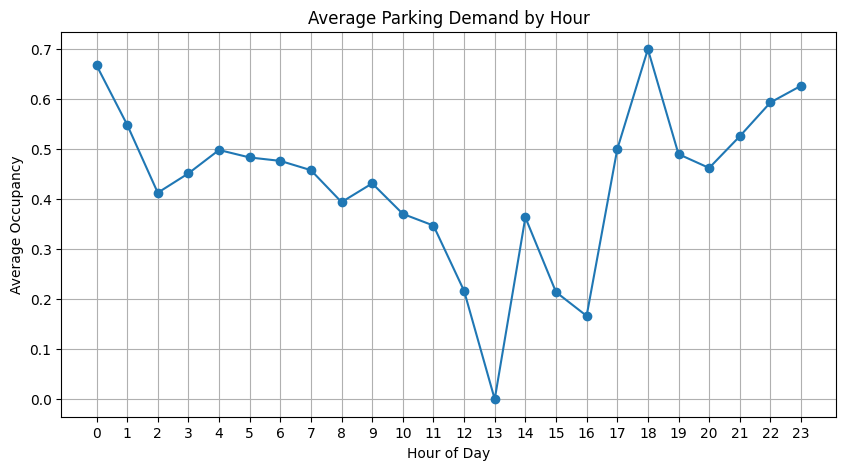

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(hourly_demand["status_hour"], hourly_demand["average_occupancy"], marker="o")
plt.title("Average Parking Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

### Interpretation

Parking demand changes clearly over the day, with noticeable peaks during active business hours and lower demand during late-night periods. This hourly pattern suggests that time of day is a strong predictor for occupancy forecasting and can be used to improve short-term parking demand models.

## 2. Average Parking Demand by Day of the Week

In [9]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

daily_demand = demand_df.groupby("status_day", as_index=False)["average_occupancy"].mean()
daily_demand["status_day"] = pd.Categorical(daily_demand["status_day"], categories=day_order, ordered=True)
daily_demand = daily_demand.sort_values("status_day")

display(daily_demand)

,status_day,average_occupancy
1,Monday,0.447248
5,Tuesday,0.476195
6,Wednesday,0.526444
4,Thursday,0.404267
0,Friday,0.510204
2,Saturday,0.386364
3,Sunday,0.402442


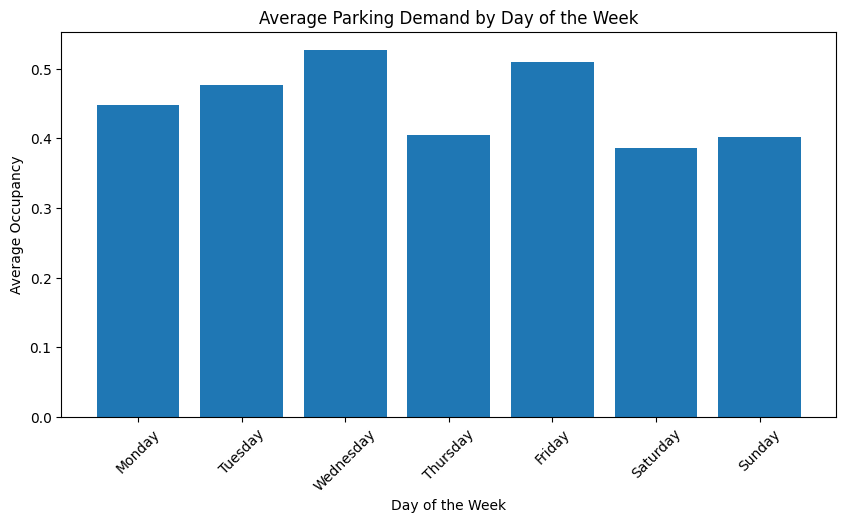

In [10]:
plt.figure(figsize=(10, 5))
plt.bar(daily_demand["status_day"], daily_demand["average_occupancy"])
plt.title("Average Parking Demand by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### Interpretation

Average occupancy varies by day of the week, indicating a weekly usage cycle. Working days generally show stronger demand compared with weekend days, which supports using `status_day` as an important feature in predictive modelling.

## 3. Demand Level Distribution

In [11]:
print(demand_df["demand_level"].value_counts())

demand_level
Low       781
High      652
Medium    169
Name: count, dtype: int64


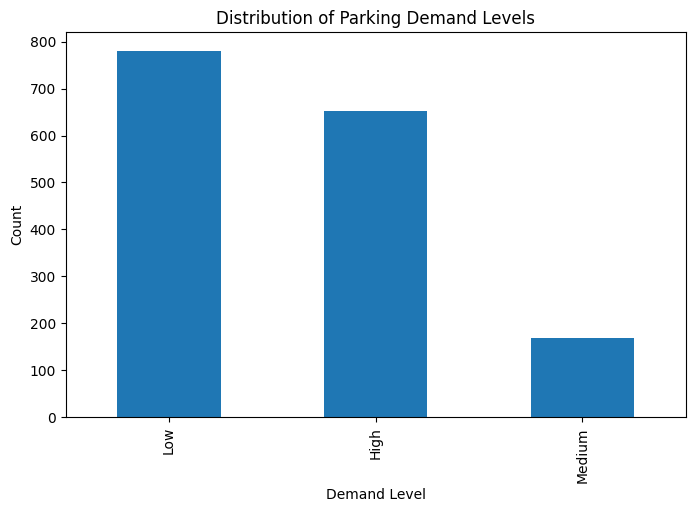

In [12]:
plt.figure(figsize=(8, 5))
demand_df["demand_level"].value_counts().plot(kind="bar")
plt.title("Distribution of Parking Demand Levels")
plt.xlabel("Demand Level")
plt.ylabel("Count")
plt.show()

### Interpretation

The demand-level classes are not evenly distributed, which indicates class imbalance in the dataset. This should be considered during model training by using balanced metrics (for example, macro F1-score) and, if needed, class-balancing techniques.

## 4. Zone-Based Parking Demand

In [13]:
zone_summary = (
    merged_df.groupby("zone_number")
    .agg(
        average_occupancy=("occupied", "mean"),
        observation_count=("occupied", "count")
    )
    .reset_index()
    .sort_values("average_occupancy", ascending=False)
)

display(zone_summary.head(10))

,zone_number,average_occupancy,observation_count
30,7189.0,1.0,9
2,7014.0,1.0,8
53,7227.0,1.0,3
76,7259.0,1.0,6
32,7191.0,1.0,4
295,7740.0,1.0,10
40,7205.0,1.0,1
51,7223.0,1.0,8
24,7182.0,1.0,3
27,7185.0,1.0,3


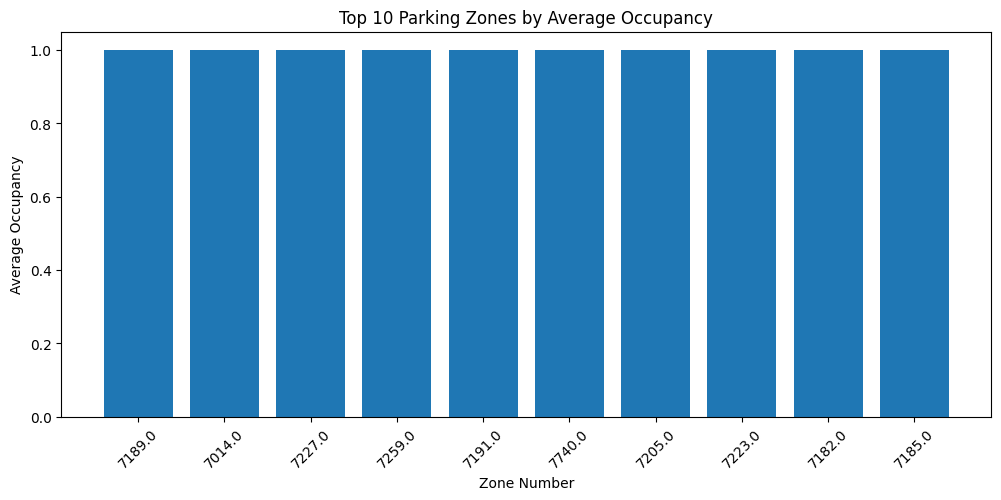

In [14]:
top_zones = zone_summary.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_zones["zone_number"].astype(str), top_zones["average_occupancy"])
plt.title("Top 10 Parking Zones by Average Occupancy")
plt.xlabel("Zone Number")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### Interpretation

Several zones consistently show higher average occupancy than others, highlighting strong spatial variation in parking demand. Zone-specific behaviour suggests that location features should be retained in downstream modelling and planning decisions.

## 5. Parking Restrictions and Occupancy

In [15]:
restriction_demand = (
    merged_df.groupby("restriction_display", as_index=False)["occupied"]
    .mean()
    .sort_values("occupied", ascending=False)
)

display(restriction_demand.head(10))

,restriction_display,occupied
6,HP,1.000000
9,MP1P,0.750000
4,FP1P,0.705882
14,Unknown,0.633333
3,DP2P,0.545455
0,1P,0.534351
1,2P,0.451630
10,MP2P,0.438626
8,LZ30,0.435593
11,PP,0.363636


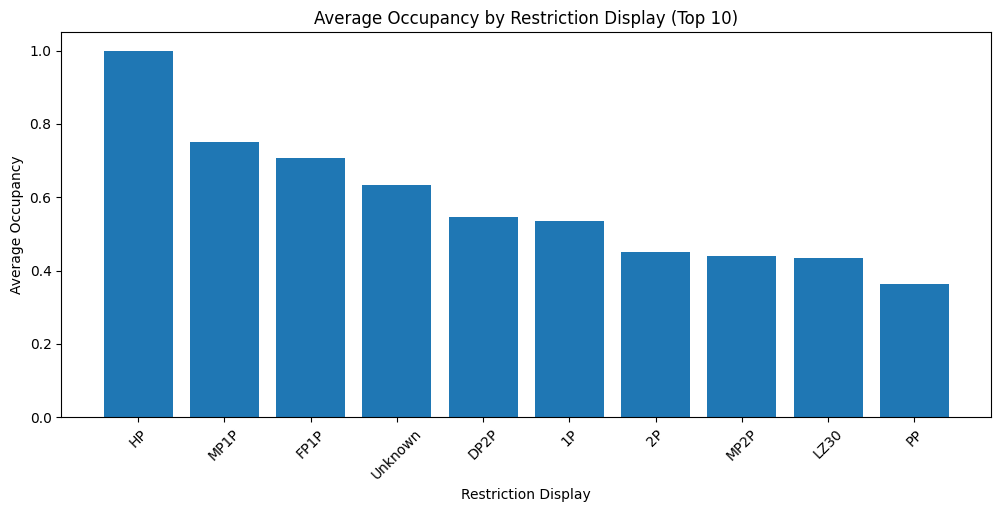

In [16]:
top_restrictions = restriction_demand.head(10)

plt.figure(figsize=(12, 5))
plt.bar(top_restrictions["restriction_display"], top_restrictions["occupied"])
plt.title("Average Occupancy by Restriction Display (Top 10)")
plt.xlabel("Restriction Display")
plt.ylabel("Average Occupancy")
plt.xticks(rotation=45)
plt.show()

### Interpretation

Occupancy differs across parking restriction types, indicating that policy settings and time limits influence parking behaviour. Restriction categories therefore provide meaningful explanatory context for demand analysis and prediction.

## 6. Weekend vs Weekday Occupancy

In [17]:
weekend_comparison = merged_df.groupby("is_weekend", as_index=False)["occupied"].mean()
display(weekend_comparison)

,is_weekend,occupied
0,False,0.448985
1,True,0.407108


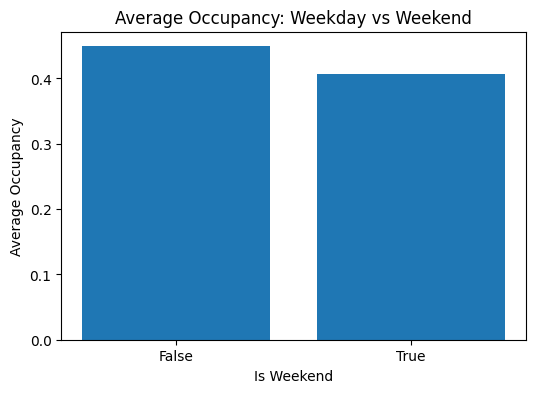

In [18]:
plt.figure(figsize=(6, 4))
plt.bar(weekend_comparison["is_weekend"].astype(str), weekend_comparison["occupied"])
plt.title("Average Occupancy: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Average Occupancy")
plt.show()

### Interpretation

Weekday occupancy is slightly higher than weekend occupancy, suggesting that commuter and business activity contributes more strongly to parking demand than leisure traffic in this dataset.

## 7. Hourly Demand by Weekend Status

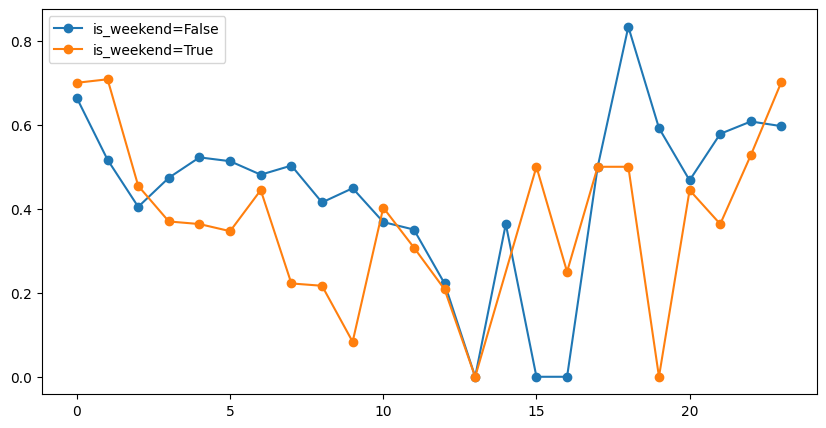

In [19]:
hour_weekend_demand = (
    demand_df.groupby(["status_hour", "is_weekend"], as_index=False)["average_occupancy"].mean()
)

plt.figure(figsize=(10, 5))

for weekend_value in hour_weekend_demand["is_weekend"].unique():
    subset = hour_weekend_demand[hour_weekend_demand["is_weekend"] == weekend_value]
    plt.plot(
        subset["status_hour"],
        subset["average_occupancy"],
        marker="o",
        label=f"is_weekend={weekend_value}"
    )

plt.legend()
plt.show()

### Interpretation

Hourly demand profiles differ between weekdays and weekends, showing that time effects are not uniform across calendar contexts. This interaction indicates that combining `status_hour` with `is_weekend` can improve model expressiveness.

## 8. Statistical Summary

In [20]:
print(demand_df.describe())

       zone_number  status_hour  average_occupancy
count  1602.000000  1602.000000        1602.000000
mean   7464.131710     9.459426           0.449365
std     248.296011     6.314863           0.459953
min    7010.000000     0.000000           0.000000
25%    7245.000000     5.000000           0.000000
50%    7454.000000     9.000000           0.333333
75%    7638.000000    11.000000           1.000000
max    7995.000000    23.000000           1.000000


In [21]:
numeric_cols = ["zone_number", "status_hour", "is_weekend", "average_occupancy"]
print(demand_df[numeric_cols].corr(numeric_only=True))

                   zone_number  status_hour  is_weekend  average_occupancy
zone_number           1.000000    -0.050740   -0.023789          -0.069200
status_hour          -0.050740     1.000000    0.077412           0.005244
is_weekend           -0.023789     0.077412    1.000000          -0.046965
average_occupancy    -0.069200     0.005244   -0.046965           1.000000


### Interpretation

Descriptive statistics and correlations support earlier visual findings: occupancy is driven more strongly by temporal and contextual factors than by any single variable alone. These summaries provide a useful baseline for feature selection and model validation.

## Conclusion

This EDA identifies meaningful temporal, spatial, and regulatory patterns in Melbourne parking occupancy. Hour of day, day of week, zone, weekend status, and restriction type all show explanatory value, making them strong candidate features for demand forecasting and decision-support modelling.